<a href="https://colab.research.google.com/github/Frankieche24/AVCAD-Assignment/blob/main/Avcad_Assigment_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Welcome to Colab!

**── Imports ──**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as sts
from scipy.optimize import minimize

**── Load & clean ──**

In [8]:
df = pd.read_csv('https://raw.githubusercontent.com/Frankieche24/AVCAD-Assignment/main/EFIplus_medit.zip', compression='zip', sep=';')
df.drop(df.iloc[:, 5:15], axis=1, inplace=True)
df.rename(columns={'Sum of Run1_number_all': 'Total_fish_individuals'}, inplace=True)
df.columns = list(map(str, df.columns))
df2 = df.dropna()

sns.set_theme(style='whitegrid', font_scale=1.05)

def clean_ax(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# ── Helper: manual logistic regression (MLE, no statsmodels dependency) ──────
def neg_log_likelihood(params, x, y):
    b0, b1 = params
    z = b0 + b1 * x
    log_p   = -np.logaddexp(0, -z)   # log(sigmoid(z))
    log_1mp = -np.logaddexp(0,  z)   # log(1 - sigmoid(z))
    return -np.sum(y * log_p + (1 - y) * log_1mp)

def fit_logistic(x, y):
    x_std = (x - x.mean()) / x.std()           # standardize for stable optimization
    res = minimize(neg_log_likelihood, x0=[0, 0], args=(x_std, y), method='BFGS')
    b0_std, b1_std = res.x
    b1 = b1_std / x.std()
    b0 = b0_std - b1_std * x.mean() / x.std()
    return b0, b1

def logistic_func(x, b0, b1):
    return 1 / (1 + np.exp(-(b0 + b1 * x)))

**PART 1 — Effect of temp_ann on Salmo trutta fario (Brown Trout) presence**

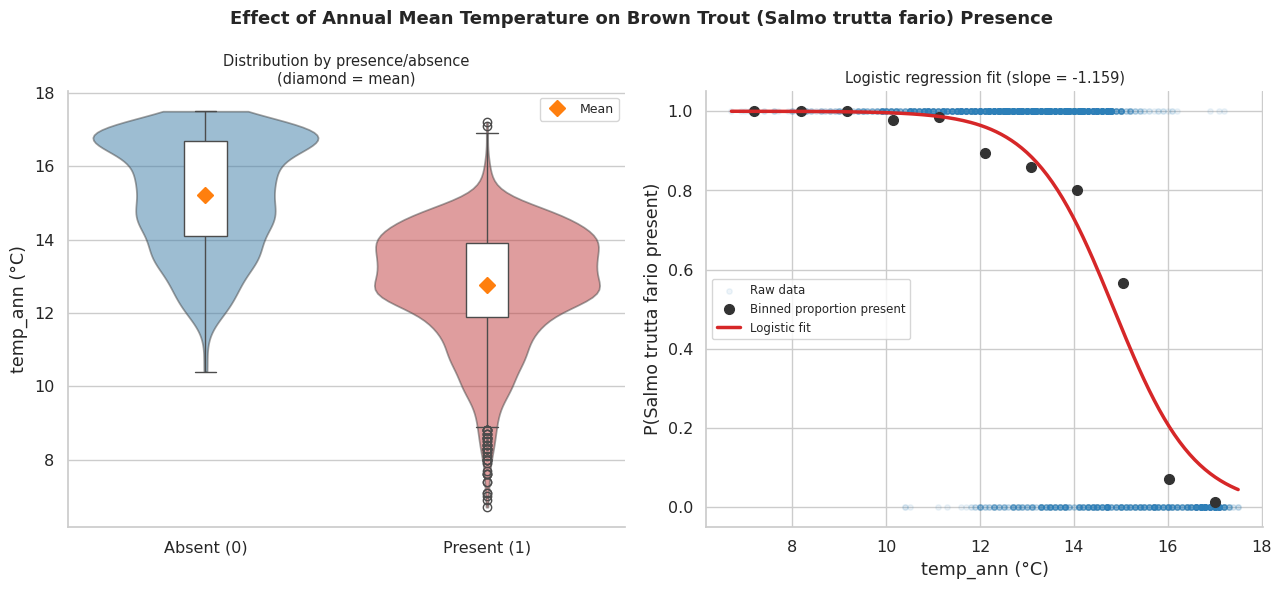

=== Part 1 ===
Present mean temp_ann: 12.75 (n=2042)
Absent mean temp_ann:  15.21 (n=780)
Mann-Whitney U: U=220336, p=1.146e-194
Logistic coefficients: intercept=17.2069, slope=-1.1585
Odds ratio per +1°C: 0.314


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
fig.suptitle('Effect of Annual Mean Temperature on Brown Trout (Salmo trutta fario) Presence',
             fontsize=13, fontweight='bold')

present = df2[df2['Salmo trutta fario'] == 1]['temp_ann']
absent  = df2[df2['Salmo trutta fario'] == 0]['temp_ann']

# Left panel: violin + box by presence/absence
ax = axes[0]
data_plot = df2[['Salmo trutta fario', 'temp_ann']].copy()
data_plot['Presence'] = data_plot['Salmo trutta fario'].map({0: 'Absent (0)', 1: 'Present (1)'})
order = ['Absent (0)', 'Present (1)']
pal = ['#d62728', '#2c7fb8']

sns.violinplot(data=data_plot, x='Presence', y='temp_ann', order=order, ax=ax,
                hue='Presence', palette=pal, legend=False, inner=None, cut=0)
for patch in ax.collections:
    patch.set_alpha(0.5)
sns.boxplot(data=data_plot, x='Presence', y='temp_ann', order=order, ax=ax,
            width=0.15, showcaps=True, boxprops={'zorder': 3, 'facecolor': 'white'},
            whiskerprops={'zorder': 3}, medianprops={'color': 'black', 'lw': 2})
for i, cat in enumerate(order):
    m = data_plot[data_plot['Presence'] == cat]['temp_ann'].mean()
    ax.plot(i, m, 'D', color='#ff7f0e', markersize=8, zorder=5, label='Mean' if i == 0 else None)

ax.set_title('Distribution by presence/absence\n(diamond = mean)', fontsize=10.5)
ax.set_xlabel('')
ax.set_ylabel('temp_ann (°C)')
ax.legend(fontsize=9)
clean_ax(ax)

# Right panel: logistic regression fit
ax2 = axes[1]
x = df2['temp_ann'].values
y = df2['Salmo trutta fario'].values
b0, b1 = fit_logistic(x, y)
xs = np.linspace(x.min(), x.max(), 200)
ys = logistic_func(xs, b0, b1)

bins = np.linspace(x.min(), x.max(), 12)
bin_centers = (bins[:-1] + bins[1:]) / 2
bin_props = [
    y[(x >= bins[i]) & (x < bins[i + 1])].mean()
    if ((x >= bins[i]) & (x < bins[i + 1])).sum() > 0 else np.nan
    for i in range(len(bins) - 1)
]

ax2.scatter(x, y, alpha=0.08, s=15, color='#2c7fb8', label='Raw data')
ax2.plot(bin_centers, bin_props, 'o', color='#333333', markersize=7, zorder=4,
         label='Binned proportion present')
ax2.plot(xs, ys, color='#d62728', lw=2.5, label='Logistic fit', zorder=5)
ax2.set_xlabel('temp_ann (°C)')
ax2.set_ylabel('P(Salmo trutta fario present)')
ax2.set_title(f'Logistic regression fit (slope = {b1:.3f})', fontsize=10.5)
ax2.set_ylim(-0.05, 1.05)
ax2.legend(fontsize=8.5, loc='center left')
clean_ax(ax2)

plt.tight_layout()
plt.savefig('p1_temp_trout.png', dpi=150, bbox_inches='tight')
plt.show()

print("=== Part 1 ===")
print(f"Present mean temp_ann: {present.mean():.2f} (n={len(present)})")
print(f"Absent mean temp_ann:  {absent.mean():.2f} (n={len(absent)})")
u, p = sts.mannwhitneyu(present, absent)
print(f"Mann-Whitney U: U={u:.0f}, p={p:.4g}")
print(f"Logistic coefficients: intercept={b0:.4f}, slope={b1:.4f}")
print(f"Odds ratio per +1°C: {np.exp(b1):.3f}")


**PART 2 — Same effect, separately for Minho and Tejo (Tagus) catchments**

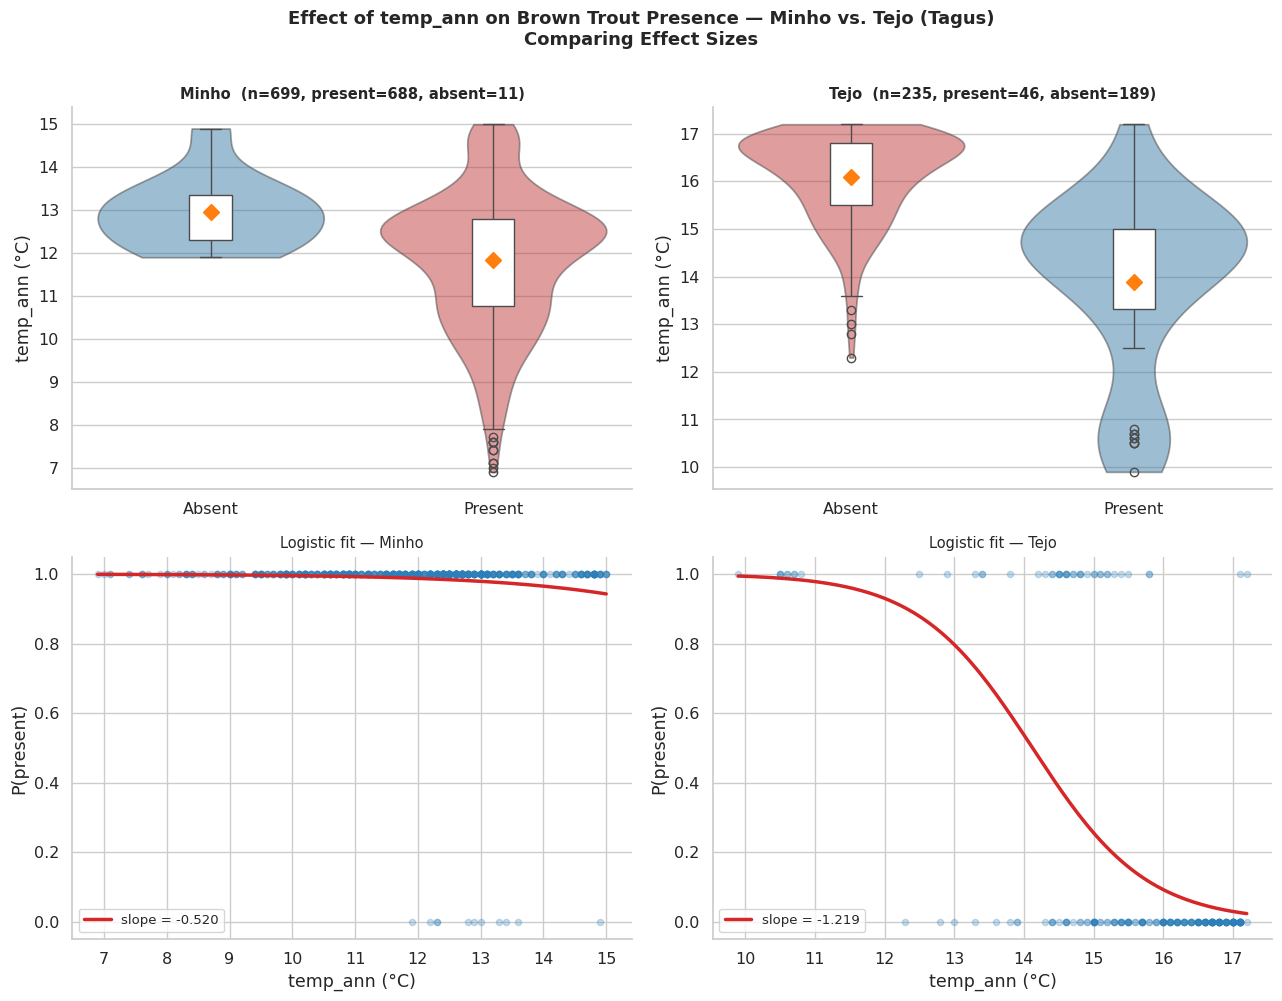


=== Part 2 ===
Minho: n=699, present=688, absent=11, logistic slope=-0.520, odds ratio/°C=0.595
Tejo: n=235, present=46, absent=189, logistic slope=-1.219, odds ratio/°C=0.296


In [10]:
catchments = ['Minho', 'Tejo']   # 'Tejo' = Tagus in this dataset
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle('Effect of temp_ann on Brown Trout Presence — Minho vs. Tejo (Tagus)\nComparing Effect Sizes',
             fontsize=13, fontweight='bold', y=1.0)

results = {}
for col_idx, catchment in enumerate(catchments):
    sub = df2[df2['Catchment_name'] == catchment]
    x = sub['temp_ann'].values
    y = sub['Salmo trutta fario'].values
    n_present = y.sum()
    n_absent = len(y) - y.sum()

    # Top row: violin + box
    ax = axes[0, col_idx]
    dp = sub[['Salmo trutta fario', 'temp_ann']].copy()
    dp['Presence'] = dp['Salmo trutta fario'].map({0: 'Absent', 1: 'Present'})
    order = ['Absent', 'Present']
    pal = ['#d62728', '#2c7fb8']
    if dp['Presence'].nunique() == 2:
        sns.violinplot(data=dp, x='Presence', y='temp_ann', order=order, ax=ax,
                        hue='Presence', palette=pal, legend=False, inner=None, cut=0)
        for patch in ax.collections:
            patch.set_alpha(0.5)
    sns.boxplot(data=dp, x='Presence', y='temp_ann', order=order, ax=ax,
                width=0.15, showcaps=True, boxprops={'zorder': 3, 'facecolor': 'white'},
                whiskerprops={'zorder': 3}, medianprops={'color': 'black', 'lw': 2})
    for i, cat in enumerate(order):
        vals = dp[dp['Presence'] == cat]['temp_ann']
        if len(vals) > 0:
            ax.plot(i, vals.mean(), 'D', color='#ff7f0e', markersize=8, zorder=5)
    ax.set_title(f'{catchment}  (n={len(sub)}, present={n_present}, absent={n_absent})',
                 fontsize=10.5, fontweight='semibold')
    ax.set_xlabel('')
    ax.set_ylabel('temp_ann (°C)')
    clean_ax(ax)

    # Bottom row: logistic fit
    ax2 = axes[1, col_idx]
    b0, b1 = fit_logistic(x, y)
    xs = np.linspace(x.min(), x.max(), 200)
    ys = logistic_func(xs, b0, b1)
    ax2.scatter(x, y, alpha=0.25, s=20, color='#2c7fb8')
    ax2.plot(xs, ys, color='#d62728', lw=2.5, label=f'slope = {b1:.3f}')
    ax2.set_xlabel('temp_ann (°C)')
    ax2.set_ylabel('P(present)')
    ax2.set_title(f'Logistic fit — {catchment}', fontsize=10.5)
    ax2.set_ylim(-0.05, 1.05)
    ax2.legend(fontsize=9.5)
    clean_ax(ax2)

    results[catchment] = dict(b0=b0, b1=b1, n=len(sub), n_present=n_present, n_absent=n_absent)

plt.tight_layout()
plt.savefig('p2_minho_tejo.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== Part 2 ===")
for c, r in results.items():
    print(f"{c}: n={r['n']}, present={r['n_present']}, absent={r['n_absent']}, "
          f"logistic slope={r['b1']:.3f}, odds ratio/°C={np.exp(r['b1']):.3f}")


**PART 3 — Is Actual_river_slope normally distributed?**

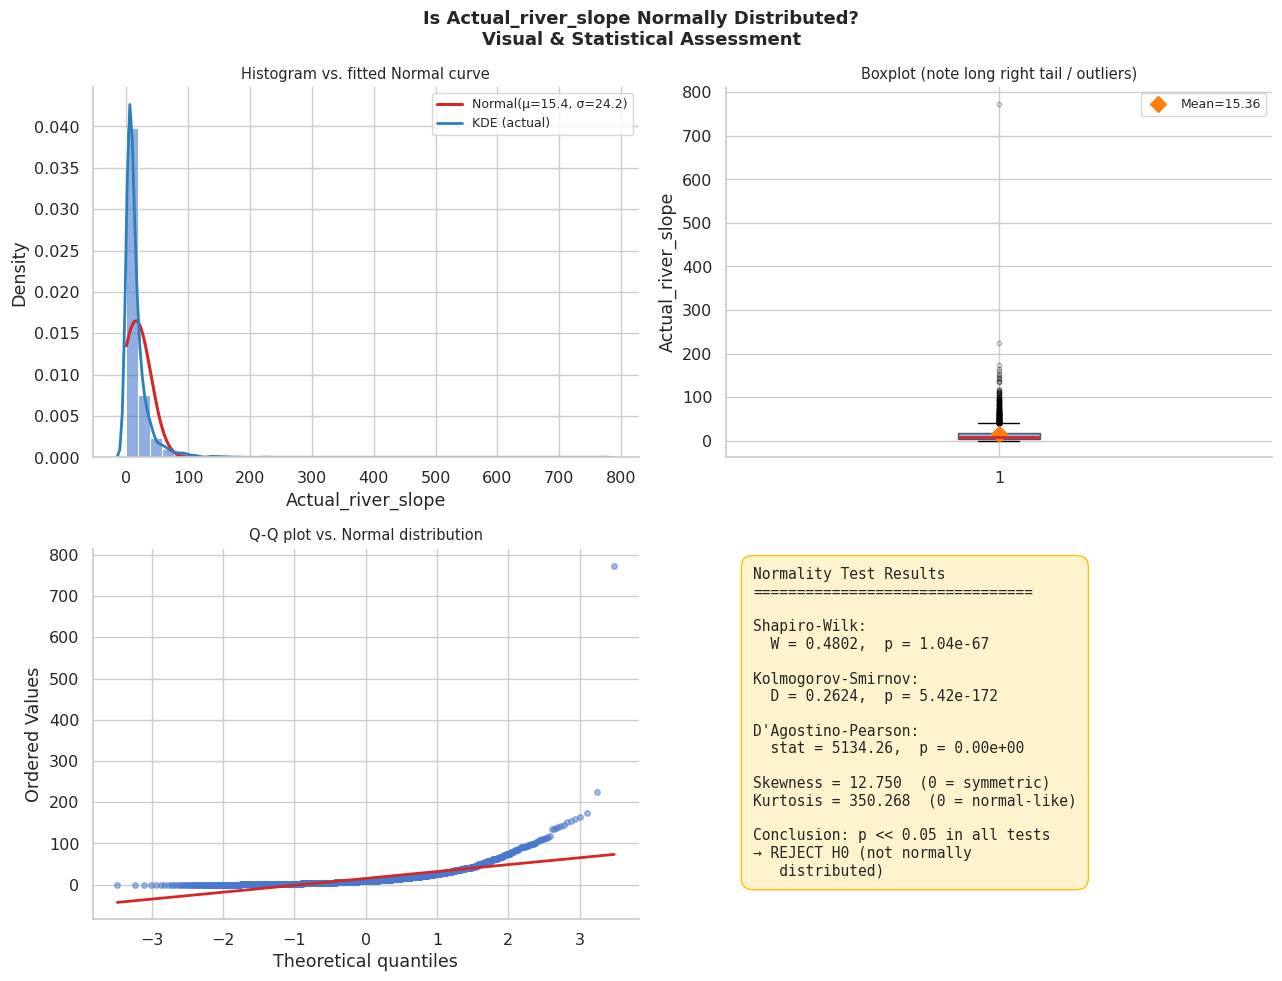


=== Part 3 ===
Shapiro-Wilk: W=0.4802, p=1.0391e-67
K-S: D=0.2624, p=5.4203e-172
D'Agostino: stat=5134.2579, p=0.0000e+00
Skewness=12.750, Kurtosis=350.268


In [11]:
slope = df2['Actual_river_slope'].values

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle('Is Actual_river_slope Normally Distributed?\nVisual & Statistical Assessment',
             fontsize=13, fontweight='bold')

# Histogram + KDE + fitted Normal
ax = axes[0, 0]
sns.histplot(slope, bins=40, stat='density', ax=ax, color='#4878cf', alpha=0.6, edgecolor='white')
xs = np.linspace(slope.min(), slope.max(), 300)
ax.plot(xs, sts.norm.pdf(xs, slope.mean(), slope.std()), color='#d62728', lw=2.2,
        label=f'Normal(μ={slope.mean():.1f}, σ={slope.std():.1f})')
sns.kdeplot(slope, ax=ax, color='#2c7fb8', lw=2, label='KDE (actual)')
ax.set_xlabel('Actual_river_slope')
ax.set_ylabel('Density')
ax.set_title('Histogram vs. fitted Normal curve', fontsize=10.5)
ax.legend(fontsize=9)
clean_ax(ax)

# Boxplot
ax2 = axes[0, 1]
ax2.boxplot(slope, vert=True, patch_artist=True,
            boxprops=dict(facecolor='#4878cf', alpha=0.6),
            medianprops=dict(color='#d62728', lw=2),
            flierprops=dict(marker='o', markersize=3, alpha=0.3))
ax2.plot(1, slope.mean(), 'D', color='#ff7f0e', markersize=8, label=f'Mean={slope.mean():.2f}')
ax2.set_ylabel('Actual_river_slope')
ax2.set_title('Boxplot (note long right tail / outliers)', fontsize=10.5)
ax2.legend(fontsize=9)
clean_ax(ax2)

# Q-Q plot
ax3 = axes[1, 0]
sts.probplot(slope, dist='norm', plot=ax3)
ax3.get_lines()[0].set_markerfacecolor('#4878cf')
ax3.get_lines()[0].set_markeredgecolor('#4878cf')
ax3.get_lines()[0].set_alpha(0.5)
ax3.get_lines()[0].set_markersize(4)
ax3.get_lines()[1].set_color('#d62728')
ax3.get_lines()[1].set_linewidth(2)
ax3.set_title('Q-Q plot vs. Normal distribution', fontsize=10.5)
clean_ax(ax3)

# Stats summary panel
ax4 = axes[1, 1]
ax4.axis('off')

# Shapiro-Wilk requires n <= 5000; subsample if needed
if len(slope) <= 5000:
    shapiro_stat, shapiro_p = sts.shapiro(slope)
else:
    shapiro_stat, shapiro_p = sts.shapiro(np.random.choice(slope, 5000, replace=False))

ks_stat, ks_p = sts.kstest(slope, 'norm', args=(slope.mean(), slope.std()))
dagostino_stat, dagostino_p = sts.normaltest(slope)
skew = sts.skew(slope)
kurt = sts.kurtosis(slope)

text = (
    f"Normality Test Results\n"
    f"{'=' * 32}\n\n"
    f"Shapiro-Wilk:\n"
    f"  W = {shapiro_stat:.4f},  p = {shapiro_p:.2e}\n\n"
    f"Kolmogorov-Smirnov:\n"
    f"  D = {ks_stat:.4f},  p = {ks_p:.2e}\n\n"
    f"D'Agostino-Pearson:\n"
    f"  stat = {dagostino_stat:.2f},  p = {dagostino_p:.2e}\n\n"
    f"Skewness = {skew:.3f}  (0 = symmetric)\n"
    f"Kurtosis = {kurt:.3f}  (0 = normal-like)\n\n"
    f"Conclusion: p << 0.05 in all tests\n"
    f"→ REJECT H0 (not normally\n   distributed)"
)
ax4.text(0.05, 0.95, text, transform=ax4.transAxes, fontsize=10.5,
          verticalalignment='top', family='monospace',
          bbox=dict(boxstyle='round', facecolor='#fff3cd', edgecolor='#ffc107', pad=0.8))

plt.tight_layout()
plt.savefig('p3_slope_normality.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== Part 3 ===")
print(f"Shapiro-Wilk: W={shapiro_stat:.4f}, p={shapiro_p:.4e}")
print(f"K-S: D={ks_stat:.4f}, p={ks_p:.4e}")
print(f"D'Agostino: stat={dagostino_stat:.4f}, p={dagostino_p:.4e}")
print(f"Skewness={skew:.3f}, Kurtosis={kurt:.3f}")


**PART 4 — Sampling distribution of the mean (100 samples, n=2000, with replacement)**

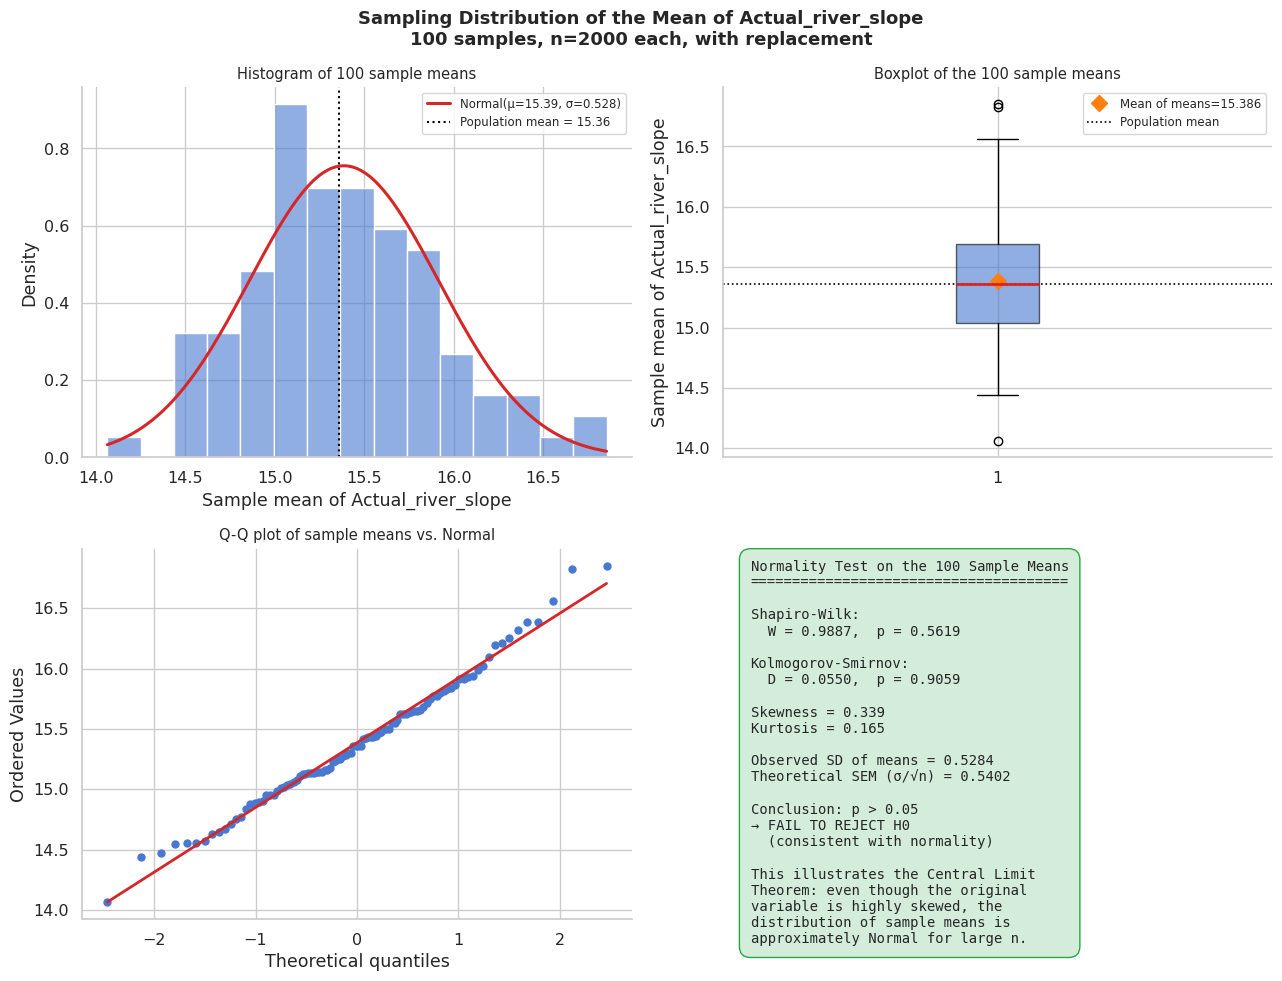


=== Part 4 ===
Mean of 100 sample means: 15.3864
SD of 100 sample means:   0.5284
Theoretical SEM:          0.5402
Shapiro-Wilk: W=0.9887, p=0.5619
K-S: D=0.0550, p=0.9059
Skew=0.339, Kurtosis=0.165


In [12]:
np.random.seed(123)
n_samples = 100
sample_size = 2000

sample_means = np.array([
    np.random.choice(slope, size=sample_size, replace=True).mean()
    for _ in range(n_samples)
])

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle('Sampling Distribution of the Mean of Actual_river_slope\n'
             '100 samples, n=2000 each, with replacement',
             fontsize=13, fontweight='bold')

# Histogram + Normal overlay
ax = axes[0, 0]
sns.histplot(sample_means, bins=15, stat='density', ax=ax, color='#4878cf',
             alpha=0.6, edgecolor='white')
xs = np.linspace(sample_means.min(), sample_means.max(), 200)
ax.plot(xs, sts.norm.pdf(xs, sample_means.mean(), sample_means.std()),
        color='#d62728', lw=2.2,
        label=f'Normal(μ={sample_means.mean():.2f}, σ={sample_means.std():.3f})')
ax.axvline(slope.mean(), color='black', ls=':', lw=1.5,
           label=f'Population mean = {slope.mean():.2f}')
ax.set_xlabel('Sample mean of Actual_river_slope')
ax.set_ylabel('Density')
ax.set_title('Histogram of 100 sample means', fontsize=10.5)
ax.legend(fontsize=8.5)
clean_ax(ax)

# Boxplot of the 100 means
ax2 = axes[0, 1]
ax2.boxplot(sample_means, vert=True, patch_artist=True,
            boxprops=dict(facecolor='#4878cf', alpha=0.6),
            medianprops=dict(color='#d62728', lw=2))
ax2.plot(1, sample_means.mean(), 'D', color='#ff7f0e', markersize=8,
         label=f'Mean of means={sample_means.mean():.3f}')
ax2.axhline(slope.mean(), color='black', ls=':', lw=1.2, label='Population mean')
ax2.set_ylabel('Sample mean of Actual_river_slope')
ax2.set_title('Boxplot of the 100 sample means', fontsize=10.5)
ax2.legend(fontsize=8.5)
clean_ax(ax2)

# Q-Q plot
ax3 = axes[1, 0]
sts.probplot(sample_means, dist='norm', plot=ax3)
ax3.get_lines()[0].set_markerfacecolor('#4878cf')
ax3.get_lines()[0].set_markeredgecolor('#4878cf')
ax3.get_lines()[0].set_markersize(5)
ax3.get_lines()[1].set_color('#d62728')
ax3.get_lines()[1].set_linewidth(2)
ax3.set_title('Q-Q plot of sample means vs. Normal', fontsize=10.5)
clean_ax(ax3)

# Stats summary panel
ax4 = axes[1, 1]
ax4.axis('off')
shapiro_stat, shapiro_p = sts.shapiro(sample_means)
ks_stat, ks_p = sts.kstest(sample_means, 'norm', args=(sample_means.mean(), sample_means.std()))
skew = sts.skew(sample_means)
kurt = sts.kurtosis(sample_means)
sem_theoretical = slope.std() / np.sqrt(sample_size)

text = (
    f"Normality Test on the 100 Sample Means\n"
    f"{'=' * 38}\n\n"
    f"Shapiro-Wilk:\n"
    f"  W = {shapiro_stat:.4f},  p = {shapiro_p:.4f}\n\n"
    f"Kolmogorov-Smirnov:\n"
    f"  D = {ks_stat:.4f},  p = {ks_p:.4f}\n\n"
    f"Skewness = {skew:.3f}\n"
    f"Kurtosis = {kurt:.3f}\n\n"
    f"Observed SD of means = {sample_means.std():.4f}\n"
    f"Theoretical SEM (σ/√n) = {sem_theoretical:.4f}\n\n"
    f"Conclusion: p > 0.05\n"
    f"→ FAIL TO REJECT H0\n"
    f"  (consistent with normality)\n\n"
    f"This illustrates the Central Limit\n"
    f"Theorem: even though the original\n"
    f"variable is highly skewed, the\n"
    f"distribution of sample means is\n"
    f"approximately Normal for large n."
)
ax4.text(0.05, 0.97, text, transform=ax4.transAxes, fontsize=10,
          verticalalignment='top', family='monospace',
          bbox=dict(boxstyle='round', facecolor='#d4edda', edgecolor='#28a745', pad=0.8))

plt.tight_layout()
plt.savefig('p4_clt_demo.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== Part 4 ===")
print(f"Mean of 100 sample means: {sample_means.mean():.4f}")
print(f"SD of 100 sample means:   {sample_means.std():.4f}")
print(f"Theoretical SEM:          {sem_theoretical:.4f}")
print(f"Shapiro-Wilk: W={shapiro_stat:.4f}, p={shapiro_p:.4f}")
print(f"K-S: D={ks_stat:.4f}, p={ks_p:.4f}")
print(f"Skew={skew:.3f}, Kurtosis={kurt:.3f}")

'Tejo' is how Tagus is labeled in Catchment_name in this dataset